Data Science Mini Project

Student Name:Gayathri S

Batch:ANB-01

Project Title:People plan campaign Data for Gram sabha and gram panchayat

Submission Date:

# 1. Problem Definition

## 1.1 Business / Real-World Problem Statement

Describe the real-world problem being addressed.

#To understand the gram panchayats and gram sabha meetings held in which how many gram panchayats are approved for the financial years from 2020-2023 across india

## 1.2 Project Objectives

Clearly state the objectives of the project.


* Analyze gram sabha and gram panchayat data .
* Build predictive models for gram panchayat approved values from total Gram panchayats.
* Compare multiple machine learning models.
* Deploy the best-performing model using FastAPI/Flask and Docker.

## 1.3 Machine Learning Problem Type

* [ ] Supervised Learning – Classification


# 2. Dataset Understanding

## 2.1 Dataset Source

Provide dataset source URL and citation.

Dataset Source: <font color='blue'>https://www.data.gov.in/datasets_webservices/datasets/7041627</font>


## 2.2 Dataset Description

Explain:

* Number of rows - 2191
* Number of columns - 10
* Dataset purpose - To check whether Gram panchayats were completely approved from total gram panchayats(0 - completely approved ,1- Not completely Approved)
* Data collection source - https://www.data.gov.in/datasets_webservices/datasets/7041627


## 2.3 Feature Description

| Feature Name | Data Type   | Description                     |
| ------------ | ----------- | --------------------------------|
| stateCode    | Numeric     | state code                      |
| stateName    | Categorical | State name                      |
| districtCode | Numeric     | District code                   |
| districtName | Categorical | District name                   |
| finYear      | Categorical | Financial Year                  |
| totalGP      | Numeric     | Total Gram Panchayats           |
| sabhaHeld    | Numeric     | Gram sabha meetings             |
| gpdpApproved | Numeric     | Gram panchayats Approved        |
| gpdpUpload   | Numeric     | Docs Uploaded for GP's Approval |
| date updated | date        | Data updated
## 2.4 Target Variable (If Applicable)

Target Variable:

* Name: gpdpApproved ('is_gpdp_fully_approved') - Binary Classification (0 or 1)
* Description: Gram Panchayats Approved
* Prediction Goal: To check whether Gram panchayats were completely approved from total gram panchayats(0 - completely approved ,1- Not completely Approved)


# 3. Exploratory Data Analysis (EDA)

## 3.1 Import Required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score


## 3.2 Load Dataset

In [2]:
df=pd.read_csv("/content/RawData.csv")

## 3.3 Dataset Overview

#Displaying the first and last 5 values
#Displaying the sample 30 values from dataset
#Looking for the null values and the datatypes of features using info
#Verifying the stats for the numerical columns using Describe

In [3]:
df.head()

,stateCode,stateName,districtCode,districtName,finYear,totalGP,sabhaHeld,gpdpApproved,gpdpUpload,date updated
0,35,ANDAMAN AND NICOBAR ISLANDS,632,NORTH AND MIDDLE ANDAMAN,2020-2021,37,37,37,37,19-02-2024
1,35,ANDAMAN AND NICOBAR ISLANDS,602,SOUTH ANDAMANS,2020-2021,30,30,30,30,19-02-2024
2,28,ANDHRA PRADESH,510,KRISHNA,2020-2021,495,981,981,979,19-02-2024
3,28,ANDHRA PRADESH,511,KURNOOL,2020-2021,484,973,973,972,19-02-2024
4,28,ANDHRA PRADESH,519,SRIKAKULAM,2020-2021,921,1190,1190,1190,19-02-2024


In [4]:
df.tail()

,stateCode,stateName,districtCode,districtName,finYear,totalGP,sabhaHeld,gpdpApproved,gpdpUpload,date updated
2185,19,WEST BENGAL,308,Cooch Behar,2022-2023,128,128,128,120,19-02-2024
2186,19,WEST BENGAL,313,HOWRAH,2022-2023,157,157,157,142,19-02-2024
2187,19,WEST BENGAL,703,Jhargram,2022-2023,79,79,79,78,19-02-2024
2188,19,WEST BENGAL,315,KOLKATA,2022-2023,0,0,0,0,19-02-2024
2189,19,WEST BENGAL,704,PASCHIM BARDHAMAN,2022-2023,62,62,62,62,19-02-2024


In [5]:
df.sample(30)

,stateCode,stateName,districtCode,districtName,finYear,totalGP,sabhaHeld,gpdpApproved,gpdpUpload,date updated
121,33,TAMIL NADU,596,VILLUPURAM,2020-2021,688,688,688,668,19-02-2024
1775,10,BIHAR,203,KISHANGANJ,2020-2021,125,126,126,126,19-02-2024
1418,9,UTTAR PRADESH,155,KANNAUJ,2020-2021,497,502,499,499,19-02-2024
2001,11,SIKKIM,742,Soreng,2021-2022,0,0,0,0,19-02-2024
1079,27,MAHARASHTRA,472,BULDHANA,2021-2022,870,870,866,823,19-02-2024
2008,33,TAMIL NADU,732,Tirupathur,2021-2022,209,209,209,209,19-02-2024
1728,33,TAMIL NADU,586,THANJAVUR,2022-2023,589,589,0,0,19-02-2024
276,12,ARUNACHAL PRADESH,229,CHANGLANG,2022-2023,132,90,15,0,19-02-2024
668,33,TAMIL NADU,573,ERODE,2021-2022,225,225,225,225,19-02-2024
1059,20,JHARKHAND,330,GODDA,2021-2022,197,197,197,197,19-02-2024


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   stateCode     2190 non-null   int64 
 1   stateName     2190 non-null   object
 2   districtCode  2190 non-null   int64 
 3   districtName  2190 non-null   object
 4   finYear       2190 non-null   object
 5   totalGP       2190 non-null   int64 
 6   sabhaHeld     2190 non-null   int64 
 7   gpdpApproved  2190 non-null   int64 
 8   gpdpUpload    2190 non-null   int64 
 9   date updated  2190 non-null   object
dtypes: int64(6), object(4)
memory usage: 171.2+ KB


In [7]:
df.describe()

,stateCode,districtCode,totalGP,sabhaHeld,gpdpApproved,gpdpUpload
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,18.073059,373.298630,352.619635,342.374886,314.816438,235.412329
std,9.874598,215.905859,301.364756,306.526899,303.610454,297.119920
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,187.000000,130.000000,113.000000,85.000000,0.000000
50%,19.000000,372.500000,269.000000,258.500000,236.000000,126.000000
75%,24.000000,560.000000,483.750000,474.000000,449.000000,359.000000
max,38.000000,764.000000,1852.000000,1860.000000,1860.000000,1858.000000


## 3.4 Missing Value Analysis


### Observations
#Verified Null values using isnull and added the values , Its Displaying as 0 .
#No Null values Present
#Checked for duplicate values using duplicated and stored the result in other variable .
#Used Value_counts to display the variable result.

In [8]:
df.isnull().sum()

,0
stateCode,0
stateName,0
districtCode,0
districtName,0
finYear,0
totalGP,0
sabhaHeld,0
gpdpApproved,0
gpdpUpload,0
date updated,0


In [9]:
duplicate_Values=df.duplicated()

In [10]:
duplicate_Values.value_counts()

,count
False,2190


## 3.5 Correlation Analysis



### Observations
#State and District are quite Correlated but they are extremely weakly correlated with other columns.
#TotalGP,sabhaheld and gpdpApproved are positively Correlated and they are badly correlated with State and District columns
#gpdpApproved and gpdpUpload are well correlated and also having a better correlation with TotalGP and sabhaheld
#Other columns like district name, state name , financial year and data updated are in categorical columns.

In [11]:
corr=df[['stateCode','districtCode','totalGP','sabhaHeld','gpdpApproved','gpdpUpload']].corr()
corr

,stateCode,districtCode,totalGP,sabhaHeld,gpdpApproved,gpdpUpload
stateCode,1.000000,0.690557,-0.063109,-0.069621,-0.089657,-0.084139
districtCode,0.690557,1.000000,-0.187931,-0.194808,-0.202803,-0.197349
totalGP,-0.063109,-0.187931,1.000000,0.966202,0.905363,0.738660
sabhaHeld,-0.069621,-0.194808,0.966202,1.000000,0.949165,0.787263
gpdpApproved,-0.089657,-0.202803,0.905363,0.949165,1.000000,0.855484
gpdpUpload,-0.084139,-0.197349,0.738660,0.787263,0.855484,1.000000


## 3.6 Visualizations

### Visualization 1

Observation:

This bar plot shows the total Gram panchayat established for 3 financial years across all the states.
Performed Grouping operations for financial year feature and added the gram panchayat values for better understanding and values displayed above each bar


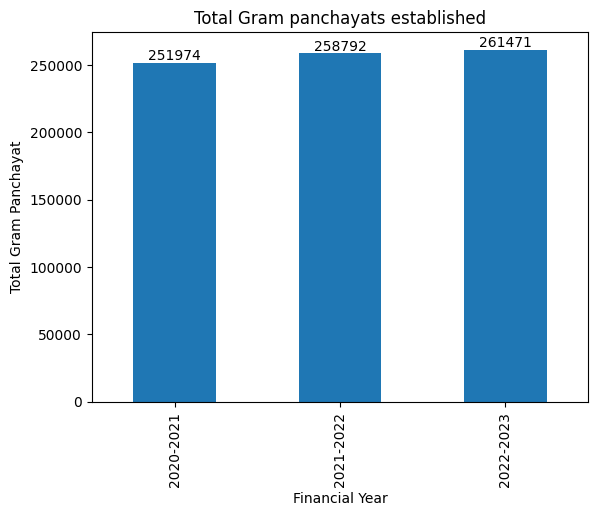

In [12]:
ax=df.groupby('finYear')['totalGP'].sum().plot(kind='bar',xlabel='Financial Year',ylabel='Total Gram Panchayat')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Total Gram panchayats established")
plt.show()

### Visualization 2



Observation:


This Histogram plot shows the count of Gram Panchayats approved across all states irrespective of year .
Basically , Histogram plot counts the values on its own and bins helps to split the range intervals .
Gram Panchayats approved less than 600 were about 1883.
Proved the results below .

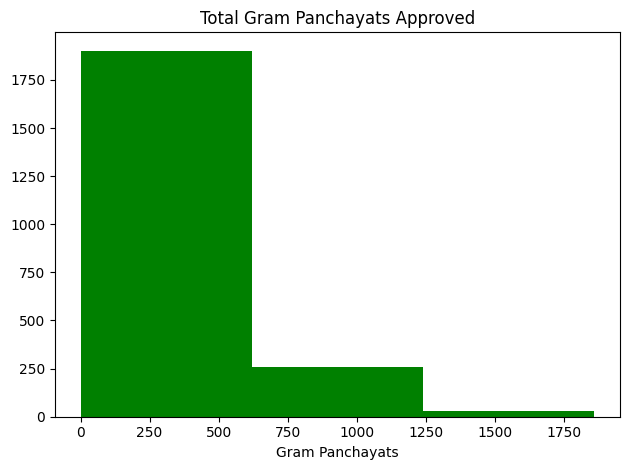

In [13]:
plt.hist(x=df['gpdpApproved'],bins=3,color='Green')
plt.xlabel("Gram Panchayats")
plt.title("Total Gram Panchayats Approved")
plt.tight_layout()
plt.show()

In [14]:
df[(df['gpdpApproved']>1250) & (df['gpdpApproved']<df['gpdpApproved'].max())].count()


,0
stateCode,31
stateName,31
districtCode,31
districtName,31
finYear,31
totalGP,31
sabhaHeld,31
gpdpApproved,31
gpdpUpload,31
date updated,31


In [15]:
df[(df['gpdpApproved']<600)].count()

,0
stateCode,1883
stateName,1883
districtCode,1883
districtName,1883
finYear,1883
totalGP,1883
sabhaHeld,1883
gpdpApproved,1883
gpdpUpload,1883
date updated,1883


### Visualization 3

Observation:
The below plot tells about the overall correlation among all the numerical columns .
we could notice totalGp, sabhaheld,gpdpapproved,gpdpupload are having good correlation among all whereas statecode and districtcode are also mapped with better correlation .

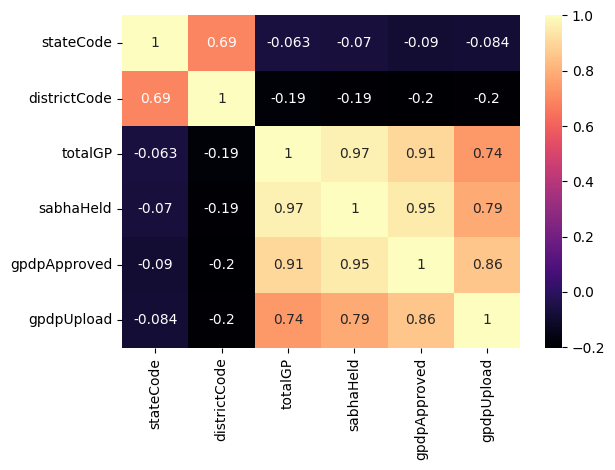

In [16]:
sns.heatmap(data=corr,annot=True,cmap='magma')
plt.tight_layout()
plt.show()

### Visualization 4


Observation:

The below scatterplot is having good linear relationship with TotalGp and Gram panchayat approved .
The Prominent diagonal line talks about the linear correlation among two features .
They are few outliers present above the diagonal lines.
small area were been approved as per total Gp raised .
We could see few data points above the diagonal line which also tells that gpdpapproved is greater than totalgp which never occurs in real condition until and unless govt accomodates supplementary fund or due to data error.

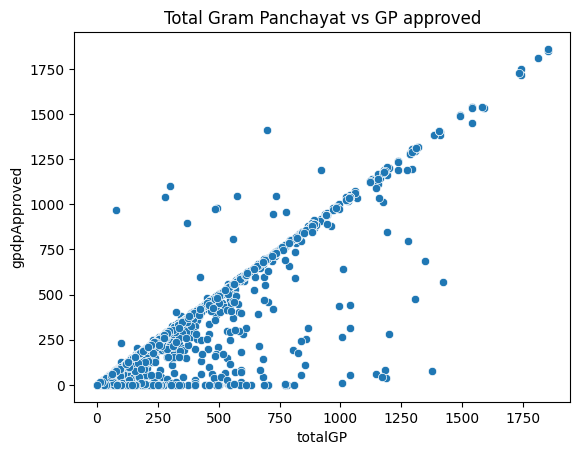

In [17]:
sns.scatterplot(data=df,x='totalGP',y='gpdpApproved')
plt.title('Total Gram Panchayat vs GP approved')
plt.show()



### Visualization 5


Observation:

The below plot shows about the state wise gram panchayat count.
we could see uttrakhand has the major gram panchayat meetings
whereas at the other end , Tripura holds the least .

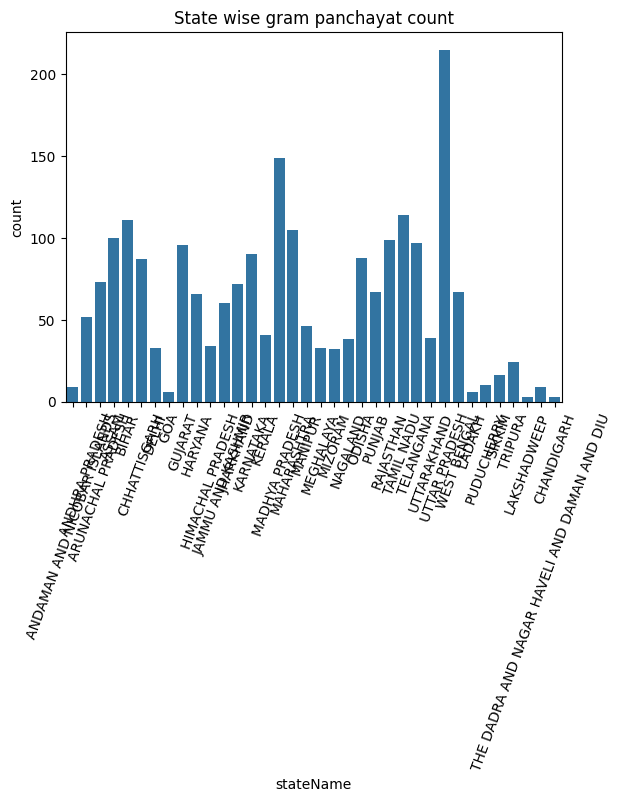

In [18]:

sns.countplot(data=df,x='stateName')
plt.xticks(rotation=70)
plt.title("State wise gram panchayat count")
plt.show()

### Visualization 6

Observation:


This plot talks about the linear correlation between gram panchayat and gram sabha meetings held .
we can see , there is a strong linear correlation between gram panchayat and gram sabha meetings held.
There is a prominent diagonal line which represent linear correlation .
There are very low cases where zero gram sabha meetings held compared to gram panchayat


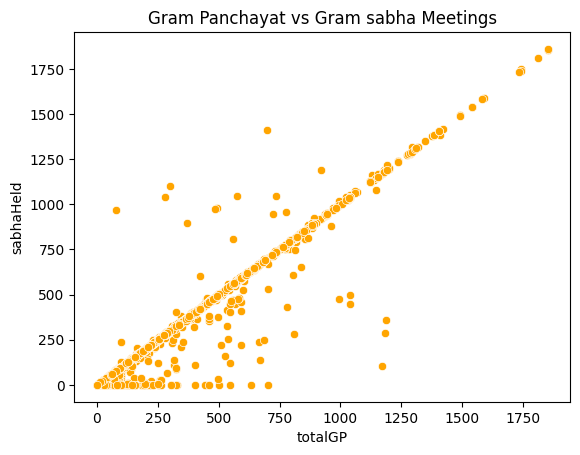

In [19]:
sns.scatterplot(data=df,x='totalGP', y='sabhaHeld',color='orange')
plt.title('Gram Panchayat vs Gram sabha Meetings')
plt.show()

### Visualization 7

Observation:


The below boxplot significantly tells about the outlier seen for totalgp,sabha held, gpdpapproved and gpdpupload

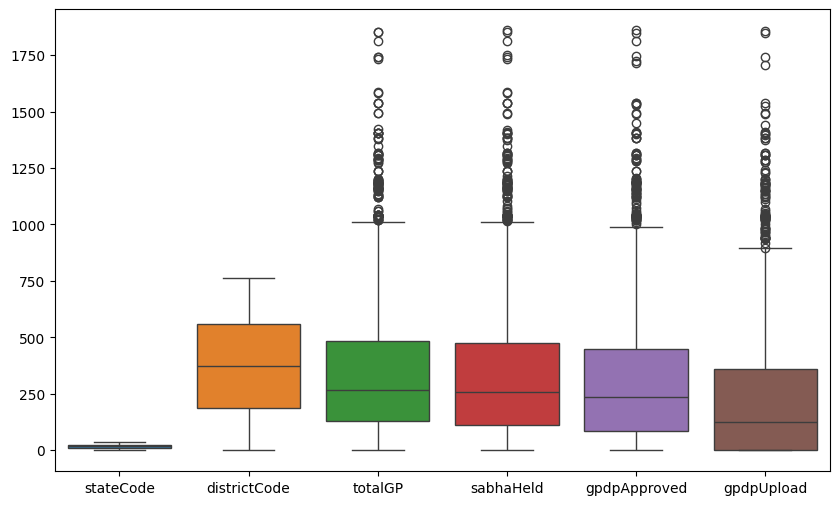

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.show()

### Visualization 8


Observation:


The below scatterplot shows the no of gp approved cases but doc upload for approval was not been uploaded .
In this condition , Most of the cases data upload was been performed equally with approved cases but also there are very bad cases where gp approved but document upload is in zero condition that's significantly very bad . We could see no data points above the diagonal line which also tells that gpdpupload is not greater than gpdpapproved


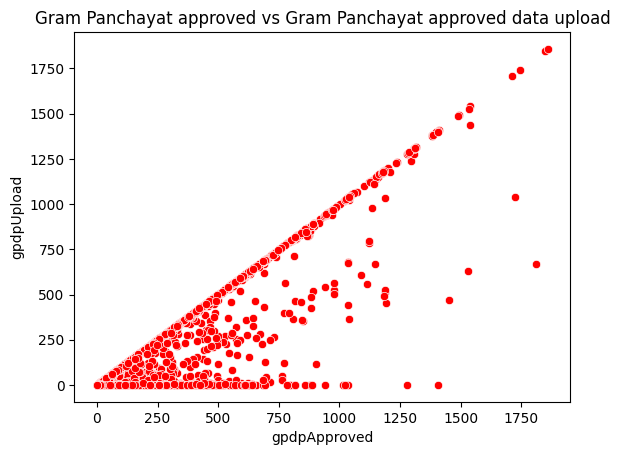

In [21]:
sns.scatterplot(data=df,x='gpdpApproved', y='gpdpUpload',color='red')
plt.title('Gram Panchayat approved vs Gram Panchayat approved data upload')
plt.show()

#Visualization 9

OBservation
The below scatterplot includes totalGp,gpdpapproved and uploaded Gram panchayats as well .X axis as totalGp and yAxis as GpdpApproved and size indicates uploaded count of approved gram panchayats . Below Prominent diagonal Line data points are seems to travel in a positive direction because all of the values attain to be same which is the overall positive note but above the diagonal line , datapoints are not seen to be in right direction because x axis values falls between 0 - 750 but y Axis is plotted across above 750 and the size indicates between 800 - 1200 . TotalGp values and gpdpapproved has some disturbed values whereas gpdpapproved and gpdpupload travels with the same direction .

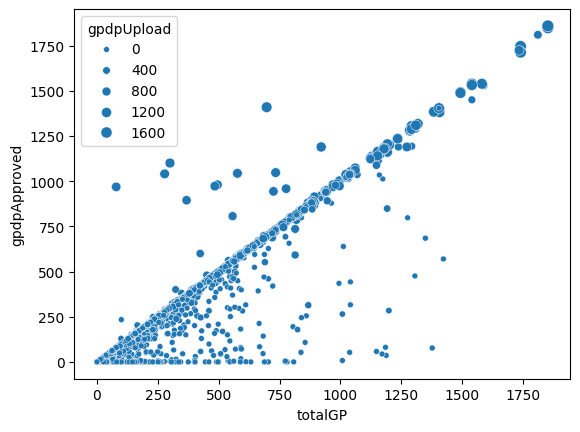

In [22]:
sns.scatterplot(data=df,x='totalGP',y='gpdpApproved',size='gpdpUpload')
plt.show()

## 3.7 Key Insights from EDA

Summarize important findings.
There are some outliers on major features related to GP and GS
approved Gram Panchayats are more than total GP which is either because of any supplementary funds allocated by the government due to floods or any data error .
In the financial year of  2022 - 2023  , major gram panchayats were established

# 4. Data Preprocessing

## 4.1 Missing Value Treatment
There are no missing or null values in Data set.

## 4.2 Duplicate Handling



Observation:
There are no duplicate values as well .
Verified both scenarios above  .

## 4.3 Outlier Detection and Treatment

### Boxplot
Boxplot was also been implemented in visualisation 7.


### IQR Method


In [23]:
Q1=np.quantile(df['totalGP'],0.25)
Q1
Q3=np.quantile(df['totalGP'],0.75)
IQR=Q3-Q1
IQR
Q1

np.float64(130.0)

In [24]:
Q1=np.quantile(df['sabhaHeld'],0.25)
Q1
Q3=np.quantile(df['sabhaHeld'],0.75)
IQR=Q3-Q1
IQR
Q1
LB=Q1-(1.5 * IQR)
UB=Q3 + (1.5 * IQR)
print(LB,UB)

-428.5 1015.5


In [25]:
LB=Q1-(1.5 * IQR)
UB=Q3 + (1.5 * IQR)
print(LB,UB)

-428.5 1015.5


In [26]:
df[(df['totalGP']<-400.625) | (df['totalGP']>1014.275)]

,stateCode,stateName,districtCode,districtName,finYear,totalGP,sabhaHeld,gpdpApproved,gpdpUpload,date updated
80,27,MAHARASHTRA,466,AHMEDNAGAR,2020-2021,1318,1318,1318,1316,19-02-2024
85,27,MAHARASHTRA,494,SATARA,2020-2021,1493,1493,1493,1492,19-02-2024
129,9,UTTAR PRADESH,129,BARABANKI,2020-2021,1160,1166,1153,1137,19-02-2024
130,9,UTTAR PRADESH,131,BASTI,2020-2021,1182,1185,1185,1178,19-02-2024
131,9,UTTAR PRADESH,137,DEORIA,2020-2021,1179,1189,1187,1185,19-02-2024
...,...,...,...,...,...,...,...,...,...,...
2169,9,UTTAR PRADESH,125,BAHRAICH,2022-2023,1041,1041,1041,363,19-02-2024
2170,9,UTTAR PRADESH,132,BIJNOR,2022-2023,1123,1123,1123,797,19-02-2024
2171,9,UTTAR PRADESH,133,BUDAUN,2022-2023,1037,1037,1037,672,19-02-2024
2175,9,UTTAR PRADESH,147,GONDA,2022-2023,1192,1189,849,354,19-02-2024


In [27]:
df[df['totalGP']>1014.275]

,stateCode,stateName,districtCode,districtName,finYear,totalGP,sabhaHeld,gpdpApproved,gpdpUpload,date updated
80,27,MAHARASHTRA,466,AHMEDNAGAR,2020-2021,1318,1318,1318,1316,19-02-2024
85,27,MAHARASHTRA,494,SATARA,2020-2021,1493,1493,1493,1492,19-02-2024
129,9,UTTAR PRADESH,129,BARABANKI,2020-2021,1160,1166,1153,1137,19-02-2024
130,9,UTTAR PRADESH,131,BASTI,2020-2021,1182,1185,1185,1178,19-02-2024
131,9,UTTAR PRADESH,137,DEORIA,2020-2021,1179,1189,1187,1185,19-02-2024
...,...,...,...,...,...,...,...,...,...,...
2169,9,UTTAR PRADESH,125,BAHRAICH,2022-2023,1041,1041,1041,363,19-02-2024
2170,9,UTTAR PRADESH,132,BIJNOR,2022-2023,1123,1123,1123,797,19-02-2024
2171,9,UTTAR PRADESH,133,BUDAUN,2022-2023,1037,1037,1037,672,19-02-2024
2175,9,UTTAR PRADESH,147,GONDA,2022-2023,1192,1189,849,354,19-02-2024


### Z-Score Method (Optional)

In [28]:
df['z_score']=stats.zscore(df['totalGP'])

In [29]:
df[df['z_score']>3]

,stateCode,stateName,districtCode,districtName,finYear,totalGP,sabhaHeld,gpdpApproved,gpdpUpload,date updated,z_score
80,27,MAHARASHTRA,466,AHMEDNAGAR,2020-2021,1318,1318,1318,1316,19-02-2024,3.204093
85,27,MAHARASHTRA,494,SATARA,2020-2021,1493,1493,1493,1492,19-02-2024,3.784918
133,9,UTTAR PRADESH,152,JAUNPUR,2020-2021,1740,1749,1747,1740,19-02-2024,4.604710
217,27,MAHARASHTRA,494,SATARA,2021-2022,1493,1489,1489,1489,19-02-2024,3.784918
260,9,UTTAR PRADESH,150,HARDOI,2021-2022,1306,1306,1294,1240,19-02-2024,3.164266
337,27,MAHARASHTRA,487,NASHIK,2022-2023,1377,1376,77,25,19-02-2024,3.399914
394,9,UTTAR PRADESH,123,AZAMGARH,2022-2023,1811,1811,1811,669,19-02-2024,4.840358
399,9,UTTAR PRADESH,150,HARDOI,2022-2023,1293,1293,1194,455,19-02-2024,3.121119
501,3,PUNJAB,32,GURDASPUR,2020-2021,1285,1279,1279,1276,19-02-2024,3.094567
631,27,MAHARASHTRA,487,NASHIK,2021-2022,1384,1384,1384,1384,19-02-2024,3.423147


Observation for Zscore:

---
Data are seems to be reliable and useful (Not Looking like outliers)

## 4.4 Skewness Treatment

### Before Transformation


In [30]:
skewvalues=stats.skew(df['totalGP'])

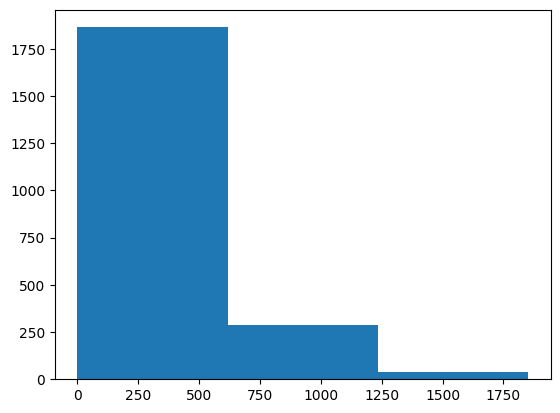

In [31]:
plt.hist(df['totalGP'],bins=3)
plt.show()

#After Transformation
used log(x) for skew Transformation
Initially , it was in right skewed (1.51) So implemented log(x) for skewness , it Pushed the Data into Left Skewed after treatment (-2.02) . So log(X) didn't work due to most of the values are very close to zero and then implemented Square root transformation and the value is quite close to 1 which is 0.3

In [32]:
df['skewtotalGp']=np.log1p(df['totalGP'])
skewvalues=stats.skew(df['skewtotalGp'])

In [33]:
skewvalues

np.float64(-2.0200766353761073)

In [34]:
skew_before = df['totalGP'].skew()
skew_after=df['skewtotalGp'].skew()


In [35]:
df.drop('skewtotalGp',axis=1,inplace=True)
print(skew_before,skew_after)

1.5198305057197392 -2.0214614615303823


In [36]:
df['sqrt_totalGP'] = np.sqrt(df['totalGP'])

In [37]:
df['sqrt_totalGP'].skew()

np.float64(0.3188919016640127)

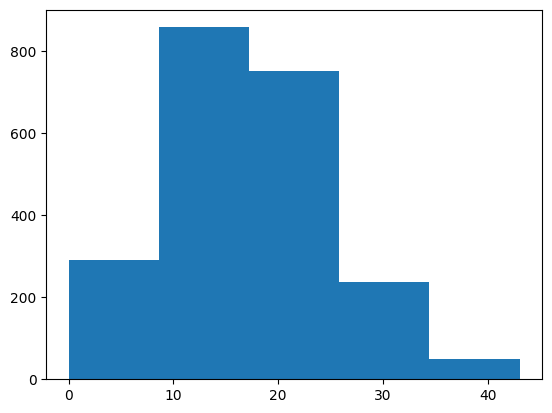

In [38]:

plt.hist(df['sqrt_totalGP'],bins=5)
plt.show()

## 4.5 Encoding

### Label Encoding
#Dropping data Updated Column , Because the date is representing the overall dataset got uploaded date , It has only one unique value
#I am not implementing label encoding technique for the state name and district Name because the data already provides state code and district code


In [39]:
le=LabelEncoder()
df['finYear']=le.fit_transform(df['finYear'])

In [40]:
#Drop data Updated Column , Because the date is representing the overall dataset got uploaded , It has only one unique value
df.drop('date updated',axis=1,inplace=True)

In [41]:
df

,stateCode,stateName,districtCode,districtName,finYear,totalGP,sabhaHeld,gpdpApproved,gpdpUpload,z_score,sqrt_totalGP
0,35,ANDAMAN AND NICOBAR ISLANDS,632,NORTH AND MIDDLE ANDAMAN,0,37,37,37,37,-1.047540,6.082763
1,35,ANDAMAN AND NICOBAR ISLANDS,602,SOUTH ANDAMANS,0,30,30,30,30,-1.070773,5.477226
2,28,ANDHRA PRADESH,510,KRISHNA,0,495,981,981,979,0.472560,22.248595
3,28,ANDHRA PRADESH,511,KURNOOL,0,484,973,973,972,0.436051,22.000000
4,28,ANDHRA PRADESH,519,SRIKAKULAM,0,921,1190,1190,1190,1.886452,30.347982
...,...,...,...,...,...,...,...,...,...,...,...
2185,19,WEST BENGAL,308,Cooch Behar,2,128,128,128,120,-0.745512,11.313708
2186,19,WEST BENGAL,313,HOWRAH,2,157,157,157,142,-0.649261,12.529964
2187,19,WEST BENGAL,703,Jhargram,2,79,79,79,78,-0.908142,8.888194
2188,19,WEST BENGAL,315,KOLKATA,2,0,0,0,0,-1.170343,0.000000


In [42]:
df['IsdpFullyApproved']=np.where(df['totalGP']==df['gpdpApproved'] , 0, 1)

In [43]:
df.drop(['stateName','districtName'],axis=1,inplace=True)
#as i have created target variable 'gpdpApproved' can be removed due to data leakage , statename and district name need not be converted into numerical column as data is present with codes of both column as features seperately . So removed those as well .

### 4.7 Train-Test Split

Implemented train_test_split before feature Scaling to avoid data leakage

In [44]:
X=df[['stateCode','finYear','totalGP','sabhaHeld','gpdpUpload','gpdpApproved']]
y=df['IsdpFullyApproved']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## 4.6 Feature Scaling

### Standardization


In [45]:
scalar=StandardScaler()
X_train=scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)

# 5. Feature Engineering & Feature Selection

## 5.1 Feature Engineering

Explain any new features created.

Created isdpFullyapproved features based on totalgp and gpdpapproved features to check whether all of the gram panchayats for each and every district is fully approved. (0 or 1)


## 5.2 Correlation-Based Feature Selection


Observation:
Considering the correlation based feature selection , statecode and districtcode feature are quite relevantly correlated compared with other features . totalGp are extremely positive correlated with sabhaheld and gpdpapproved features whereas gpdpupload is positively correlated with totalGp.At the same end , gpdpupload is having positive correlation with gpdpapproved compared with others . So I have pushed districtcode,totalGp,sabhaheld,gpdpapproved and gpdpupload as my independent Variable .


In [46]:
corr

,stateCode,districtCode,totalGP,sabhaHeld,gpdpApproved,gpdpUpload
stateCode,1.000000,0.690557,-0.063109,-0.069621,-0.089657,-0.084139
districtCode,0.690557,1.000000,-0.187931,-0.194808,-0.202803,-0.197349
totalGP,-0.063109,-0.187931,1.000000,0.966202,0.905363,0.738660
sabhaHeld,-0.069621,-0.194808,0.966202,1.000000,0.949165,0.787263
gpdpApproved,-0.089657,-0.202803,0.905363,0.949165,1.000000,0.855484
gpdpUpload,-0.084139,-0.197349,0.738660,0.787263,0.855484,1.000000


## 5.3 SelectKBest

Observation
SelectKbest is used below for feature selection using score function as f_classif and also asked to select top most 5 features among 6 . After performing fittotransform  method ,
displayed scores below to compare the features and passed my target variable as well (isdpfullyapproved) .
SelectKbest method selected 5 features which are districtcode,finyear,totalgp,sabhaheld and gpdpupload

In [47]:
select = SelectKBest(score_func=f_classif,k=5)
X_new=select.fit_transform(X,y)

In [48]:
print(X_new.shape)

(2190, 5)


In [49]:
print(X.shape)

(2190, 6)


In [50]:
select.scores_


array([ 22.98562938, 178.54595167,  20.77405982,   8.43750154,
        38.12412916,   1.7089611 ])

In [57]:
df[df['finYear']==1]

,stateCode,districtCode,finYear,totalGP,sabhaHeld,gpdpApproved,gpdpUpload,z_score,sqrt_totalGP,IsdpFullyApproved
144,35,602,1,30,30,30,30,-1.070773,5.477226,0
145,28,515,1,725,722,722,720,1.235929,26.925824,1
146,12,229,1,132,129,117,107,-0.732236,11.489125,1
147,12,718,1,67,67,55,23,-0.947970,8.185353,1
148,18,299,1,28,28,0,0,-1.077411,5.291503,1
...,...,...,...,...,...,...,...,...,...,...
2033,9,177,1,884,868,864,845,1.763649,29.732137,1
2034,19,313,1,157,157,157,157,-0.649261,12.529964,0
2035,19,318,1,211,211,211,210,-0.470035,14.525839,0
2036,19,321,1,170,170,170,170,-0.606114,13.038405,0


In [55]:
selected_indices = select.get_support(indices=True)
df

,stateCode,districtCode,finYear,totalGP,sabhaHeld,gpdpApproved,gpdpUpload,z_score,sqrt_totalGP,IsdpFullyApproved
0,35,632,0,37,37,37,37,-1.047540,6.082763,0
1,35,602,0,30,30,30,30,-1.070773,5.477226,0
2,28,510,0,495,981,981,979,0.472560,22.248595,1
3,28,511,0,484,973,973,972,0.436051,22.000000,1
4,28,519,0,921,1190,1190,1190,1.886452,30.347982,1
...,...,...,...,...,...,...,...,...,...,...
2185,19,308,2,128,128,128,120,-0.745512,11.313708,0
2186,19,313,2,157,157,157,142,-0.649261,12.529964,0
2187,19,703,2,79,79,79,78,-0.908142,8.888194,0
2188,19,315,2,0,0,0,0,-1.170343,0.000000,0


In [53]:
selected_indices
print("Selected Features for Performing Model building and prediction using selectKbest Feature selection method")
for i in selected_indices:
   print(X.columns[i])

Selected Features for Performing Model building and prediction using selectKbest Feature selection method
stateCode
finYear
totalGP
sabhaHeld
gpdpUpload


## 5.4 Final Feature Set

List selected features and justify selection.
stateCode- It Provides the Gram panchayat established states code across india.
TotalGp - Total Gram Panchayats meeting held across all the states is one of the most relevant feature to create a new target variable.
sabhaheld - Gram sabha meetings held across all the states which holds data of the gram sabha and scores are really good on both selection .
gpdpupload - Gram Panchayats Approved data upload values holds data about the GP Approved doc Upload which also scored really well .
finYear- This data holds the values about the financial year of each GP.

# 6. Model Building

## 6.1 Baseline Model

Build a baseline model.
#6.2 Model 1

#Logistic Regression

In [ ]:
logisticModel=LogisticRegression()


In [ ]:
X_logtrain=logisticModel.fit(X_train,y_train)

In [ ]:
X_new=logisticModel.predict(X_test)

In [ ]:
print(accuracy_score(y_test,X_new))

0.6621004566210046


## 6.2 Model 2

Model Name: Decision Tree



In [ ]:
tree=DecisionTreeClassifier()

In [ ]:
X_treetrain=tree.fit(X_train,y_train)

In [ ]:
y_predtree=tree.predict(X_test)

In [ ]:
print(accuracy_score(y_test,y_predtree))

0.7853881278538812


#Results :
Implemented Decision Tree classifier
Performed both fit and predict
Calculated the accuracy score of the decision tree model which is 80% greater than logistic regression.

## 6.3 Model 3

Model Name:KNN


In [ ]:
neighbour=KNeighborsClassifier(n_neighbors=2)

In [ ]:
X_neightrain=tree.fit(X_train,y_train)

In [ ]:
y_predneigh=tree.predict(X_test)

In [ ]:
print(accuracy_score(y_test,y_predneigh))

0.7922374429223744


#Results :
Implemented KNeighbours Classifier.
Performed both fit and predict methods .
Calculated accuracy score comparing both actual test value and newly predicted value and it scored 78% which is almost closer to Decision Tree but definitely more than Logistic regression


## 6.4 Model 4

Model Name:
Random Forest

In [ ]:
forestModel=RandomForestClassifier(n_estimators=100,max_depth=12,min_samples_split=20,max_features='sqrt',min_samples_leaf=10)

In [ ]:
forestModel.fit(X_train,y_train)


RandomForestClassifier(max_depth=12, min_samples_leaf=10, min_samples_split=20)

In [ ]:
y_predforest=forestModel.predict(X_test)
X_predforest=forestModel.predict(X_train)
importance=pd.Series(forestModel.feature_importances_)
importance

,0
0,0.247816
1,0.207992
2,0.155030
3,0.114459
4,0.274703


In [ ]:
print(accuracy_score(y_test,y_predforest))
print(accuracy_score(y_train,X_predforest))

0.8059360730593608
0.8344748858447488


#Results :
Implemented Random forest Classifier .
Performed both predict and fit methods .
calculated accuracy score which is also very much closer to KNN , Decision tree but definitely greater than logistic regression.

## 6.5 Model 5

Model name:SVM



In [ ]:
svmmodel=SVC()

In [ ]:
X_SVMtrain=svmmodel.fit(X_train,y_train)

In [ ]:
y_SVMPred=svmmodel.predict(X_test)

In [ ]:
print(accuracy_score(y_test,y_SVMPred))

0.728310502283105


#Results :
Implemented SVM Classifier . Performed both predict and fit methods.Calculated Accuracy Score which is less than KNN Random forest and decision but Greater than logistic regression .

# 7. Model Evaluation & Comparison

## 7.1 Evaluation Metrics

### Classification Projects

* Accuracy
* Precision
* Recall
* F1 Score
* ROC-AUC



In [ ]:
classifiers={
    'Logistic Regression':LogisticRegression(),
    'Decision tree':DecisionTreeClassifier(),
    'KNN' : KNeighborsClassifier(),
    'Random Forest':RandomForestClassifier(),
    'SVM':SVC()
}
Results={}
for name,models in classifiers.items():
  print(name)
  models.fit(X_train,y_train)
  y_pred=models.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred)
  recall=recall_score(y_test,y_pred)
  f1score=f1_score(y_test,y_pred)
  rocauc=roc_auc_score(y_test,y_pred)
  scoreavg=(accuracy+precision+recall+f1score+rocauc)/5
  Results[name]={'Accuracy':accuracy,'Precision':precision,'Recall':recall,'f1score':f1score,'ROC-AUC':rocauc,'ScoreAvg':scoreavg}
sortedResults=dict(sorted(Results.items(),key=lambda item:item[1]["ScoreAvg"],reverse=True))
print(Results)

Logistic Regression
Decision tree
KNN
Random Forest
SVM
{'Logistic Regression': {'Accuracy': 0.6621004566210046, 'Precision': 0.6789473684210526, 'Recall': 0.5972222222222222, 'f1score': 0.6354679802955665, 'ROC-AUC': np.float64(0.6612237237237237), 'ScoreAvg': np.float64(0.6469923502567139)}, 'Decision tree': {'Accuracy': 0.7899543378995434, 'Precision': 0.803921568627451, 'Recall': 0.7592592592592593, 'f1score': 0.780952380952381, 'ROC-AUC': np.float64(0.7895395395395396), 'ScoreAvg': np.float64(0.7847254172556349)}, 'KNN': {'Accuracy': 0.7511415525114156, 'Precision': 0.7688442211055276, 'Recall': 0.7083333333333334, 'f1score': 0.7373493975903614, 'ROC-AUC': np.float64(0.7505630630630632), 'ScoreAvg': np.float64(0.7432463135207403)}, 'Random Forest': {'Accuracy': 0.8013698630136986, 'Precision': 0.8177339901477833, 'Recall': 0.7685185185185185, 'f1score': 0.7923627684964201, 'ROC-AUC': np.float64(0.800925925925926), 'ScoreAvg': np.float64(0.7961822132204693)}, 'SVM': {'Accuracy': 0.

In [ ]:
resultsDf=pd.DataFrame(sortedResults).T

In [ ]:
resultsDf

,Accuracy,Precision,Recall,f1score,ROC-AUC,ScoreAvg
Random Forest,0.801370,0.817734,0.768519,0.792363,0.800926,0.796182
Decision tree,0.789954,0.803922,0.759259,0.780952,0.789540,0.784725
KNN,0.751142,0.768844,0.708333,0.737349,0.750563,0.743246
SVM,0.728311,0.734300,0.703704,0.718676,0.727978,0.722594
Logistic Regression,0.662100,0.678947,0.597222,0.635468,0.661224,0.646992


In [ ]:
resultsDf['Rank']=[1,2,3,4,5]

In [ ]:
resultsDf


,Accuracy,Precision,Recall,f1score,ROC-AUC,ScoreAvg,Rank
Random Forest,0.801370,0.817734,0.768519,0.792363,0.800926,0.796182,1
Decision tree,0.789954,0.803922,0.759259,0.780952,0.789540,0.784725,2
KNN,0.751142,0.768844,0.708333,0.737349,0.750563,0.743246,3
SVM,0.728311,0.734300,0.703704,0.718676,0.727978,0.722594,4
Logistic Regression,0.662100,0.678947,0.597222,0.635468,0.661224,0.646992,5


## 7.3 Best Model Selection

Explain:
Random Forest is selected because it got a very good score comparatively with other models on  average .

Strengths :
Single decision trees easily overfit but random forest averages out individual errors across many uncorrelated trees.
It manages with a thousand input dimensions without feature reduction.
Outliers or random noise will not affect the prediction of random forest because it affects only the tiny parts of trees in the forest if that really scores low variance ignored.
It works well both in Classification and Regression algorithms.

Limitations:
As it process with hundreds of trees , it requires substantial memory and processing power .

Training can happen simultaneously with many numbers of trees but prediction needs to query every single tree which can cause latency issues.

Saving a fully trained random forest model which requires more space resulting in massive sizes .

## 7.4 Overfitting / Underfitting Analysis

Discuss:

* Training Performance - 0.9994292237442922
Training data Performed really well of accuracy score 99%

* Testing Performance - 0.7945205479452054
Training accuracy combined with testing accuracy means random forest essentially memorized the training data instead of finding out the learning pattern because it has got the absolute differences of 20% . As training performance is high , we can say , its severely Overfitting .

Generalization capability - Performed hyperparameter tuning for the best configuration setting to balance bias - Variance .
As Model predicts high variance with low bias (Overfitting) ,
performing hyperparameter tuning with gridSearchCrossvalidation results the parameter with values below
n_estimators=100,max_depth=12,min_samples_split=20,max_features='sqrt',min_samples_leaf=10
which minimizes the training accuracy and balances the both training and testing accuracy with
0.8361872146118722 and 0.8036529680365296
This model has achieved good generalization capability.
The Training score with 83.6 has 3.2 total difference with the testing score which successfully prevented my model from memorizing the noise but allowed me to maintain predictive performance on unseen data .
Overfitting - A minimal Gap with 3.2 low variance   
Underfitting - passed and scores are strong with low bias .





In [ ]:
param_dist = {
    'max_depth': [5, 8, 12],
    'min_samples_split':[5,10,20],
    'min_samples_leaf':[10,20,30],
    'n_estimators': [100, 200]
}

# 5-Fold Cross Validation search

rf_search = GridSearchCV(estimator=forestModel, param_grid=param_dist, cv=5, verbose=1,n_jobs=-1)
rf_search.fit(X_train, y_train)

print(f"Best parameters for generalization: {rf_search.best_params_}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits


KeyboardInterrupt: 